In [ ]:
import cv2
from google.colab import drive
from pathlib import Path
import shutil
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
#CARGA DE IMAGEN CÁMARA OSCURA


drive.mount("/content/drive")

im_originales = Path("/content/drive/MyDrive/2026/Técnicas de Procesamiento Digital de Imágenes - Matias Barreto/GITHUB REPO PROFE/cornes-valeria-pdi-1c-2026/TP_006/TP 006/IMAGENES/ORIGINALES/camara_001.jpeg")
im_procesadas= Path("/content/drive/MyDrive/2026/Técnicas de Procesamiento Digital de Imágenes - Matias Barreto/GITHUB REPO PROFE/cornes-valeria-pdi-1c-2026/TP_006/TP 006/IMAGENES/PROCESADAS/")

ruta_destino_camara = im_procesadas
shutil.copy(im_originales, ruta_destino_camara)

print(f"Imagen copiada a: {ruta_destino_camara.resolve()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Imagen copiada a: /content/drive/MyDrive/2026/Técnicas de Procesamiento Digital de Imágenes - Matias Barreto/GITHUB REPO PROFE/cornes-valeria-pdi-1c-2026/TP_006/TP 006/IMAGENES/PROCESADAS


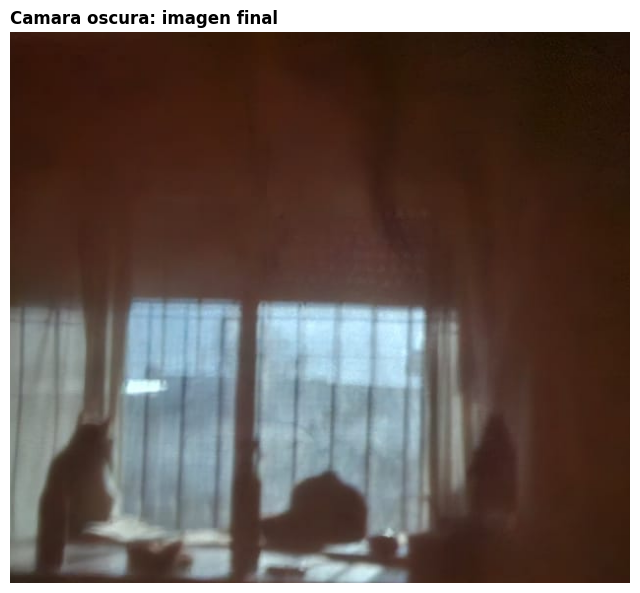

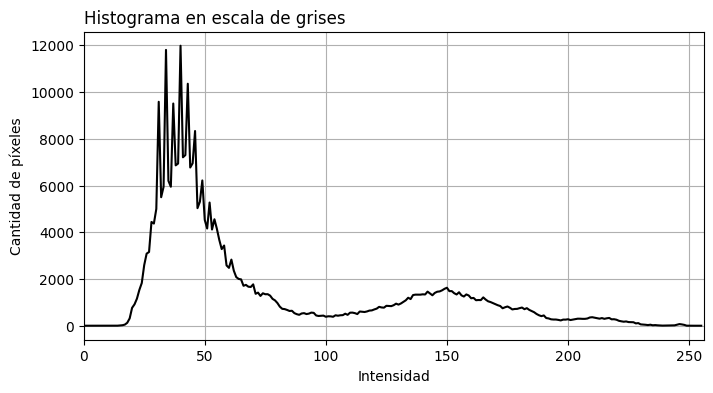

In [ ]:
nombre_imagen_camara_oscura = "camara_001.jpeg"

def cargar_rgb(ruta):
    """Abre una imagen color y la devuelve en formato RGB."""
    # Leemos la imagen con OpenCV en formato BGR.
    imagen_bgr = cv2.imread(str(ruta), cv2.IMREAD_COLOR)

    # Verificamos que la lectura haya sido correcta.
    if imagen_bgr is None:
        raise FileNotFoundError(f"No se pudo leer la imagen: {ruta}")

    # Convertimos de BGR a RGB para visualizar correctamente con Matplotlib.
    imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)
    return imagen_rgb

if nombre_imagen_camara_oscura != "":
    ruta_camara_oscura = im_procesadas / nombre_imagen_camara_oscura
    imagen_camara_oscura_rgb = cargar_rgb(ruta_camara_oscura)


# Rotamos la imagen original 180 grados.

imagen_camara_oscura_rgb = cv2.rotate(
    imagen_camara_oscura_rgb,
    cv2.ROTATE_180
)

# =========================
# RECORTE DE LA PROYECCION
# =========================

# imagen[y1:y2, x1:x2]

camara_oscura_recorte = imagen_camara_oscura_rgb[
    520:1080,
    60:690
]


def mostrar_imagen(imagen, titulo="camara_oscura final"):
    plt.figure(figsize=(8, 10))
    plt.imshow(imagen)
    plt.title(titulo, fontweight="bold", loc="left")
    plt.axis("off")
    plt.show()


def mostrar_histograma_gris(imagen):
    if imagen is None:
        print("Error: la imagen no está cargada")
        return

    # Convertir a gris
    imagen_gris = cv2.cvtColor(imagen, cv2.COLOR_RGB2GRAY)

    # Asegurar tipo correcto
    imagen_gris = imagen_gris.astype(np.uint8)

    # Calcular histograma
    hist = cv2.calcHist([imagen_gris], [0], None, [256], [0,256])

    # Mostrar
    plt.figure(figsize=(8,4))
    plt.plot(hist, color='black')
    plt.title("Histograma en escala de grises", loc="left")
    plt.xlabel("Intensidad")
    plt.ylabel("Cantidad de píxeles")
    plt.xlim([0,256])
    plt.grid()
    plt.show()

mostrar_imagen(camara_oscura_recorte, "Camara oscura: imagen final")
mostrar_histograma_gris(camara_oscura_recorte)

En el histograma se observa una concentración de valores en zonas bajas y medias de intensidad. Esto indica que la imagen presenta bajo brillo y poco contraste, algo esperable en una captura realizada mediante cámara oscura, donde la cantidad de luz que atraviesa el orificio es limitada. La mayor parte de los píxeles se concentra en regiones oscuras, generando una imagen tenue y con poca separación tonal.

In [ ]:
# =========================
# CONVERSION A HSV
# =========================

camara_oscura_hsv = cv2.cvtColor(
    camara_oscura_recorte,
    cv2.COLOR_RGB2HSV
)

# Separamos canales
h, s, v = cv2.split(camara_oscura_hsv)


Se utilizó CLAHE sobre el canal V para mejorar el contraste de la proyección sin producir una ecualización global excesiva. Esto permite conservar mejor la lectura visual de la imagen y evitar zonas sobreexpuestas o dominantes cromáticas demasiado intensas

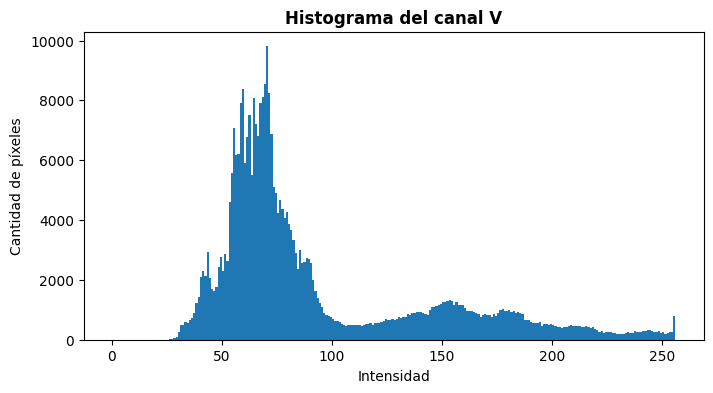

In [ ]:
# =========================
# HISTOGRAMA DEL CANAL V
# =========================

plt.figure(figsize=(8, 4))

plt.hist(
    v.ravel(),
    bins=256,
    range=(0, 256)
)

plt.title(
    "Histograma del canal V",
    fontweight="bold"
)

plt.xlabel("Intensidad")
plt.ylabel("Cantidad de píxeles")

plt.show()

Luego de aplicar CLAHE sobre el canal V, los valores de intensidad se distribuyen de forma más amplia a lo largo del histograma. Esto mejora la separación entre luces y sombras y aumenta el contraste local de la imagen. A diferencia de una ecualización global tradicional, CLAHE permite realizar una mejora más controlada, evitando una sobreexposición excesiva y reduciendo la aparición de saturaciones artificiales.

In [ ]:
# =========================
# ECUALIZACION SUAVE CON CLAHE
# =========================

clahe = cv2.createCLAHE(
    clipLimit=1.5,
    tileGridSize=(8, 8)
)

v_ecualizado = clahe.apply(v)

In [ ]:
# =========================
# RECONSTRUCCION DE LA IMAGEN
# =========================

# Unimos nuevamente los canales HSV:
# H mantiene el tono/color original,
# S mantiene la saturación original,
# V usa el brillo mejorado con CLAHE.
camara_oscura_hsv_ecualizada = cv2.merge([h, s, v_ecualizado])

# Convertimos la imagen desde HSV a RGB para poder visualizarla correctamente.
camara_oscura_ecualizada_rgb = cv2.cvtColor(
    camara_oscura_hsv_ecualizada,
    cv2.COLOR_HSV2RGB
)





In [ ]:
# =========================
# HSV → RGB
# =========================

camara_oscura_ecualizada_rgb = cv2.cvtColor(
    camara_oscura_hsv_ecualizada,
    cv2.COLOR_HSV2RGB
)

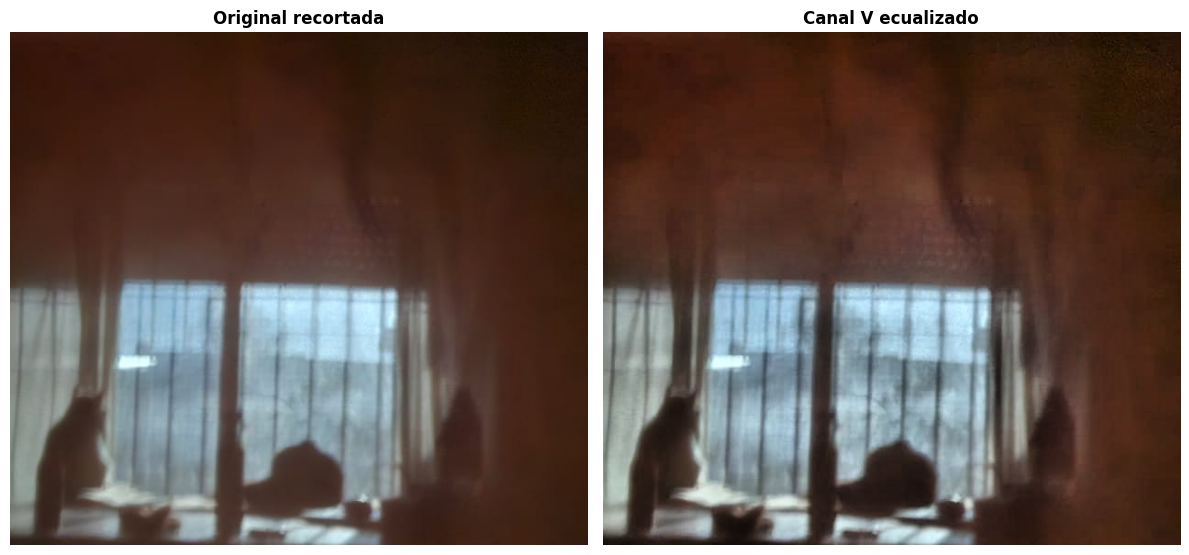

In [ ]:
# =========================
# COMPARACION VISUAL
# =========================

plt.figure(figsize=(12, 8))

plt.subplot(1, 2, 1)
plt.imshow(camara_oscura_recorte)
plt.title(
    "Original recortada",
    fontweight="bold"
)
plt.axis("off")


plt.subplot(1, 2, 2)
plt.imshow(camara_oscura_ecualizada_rgb)
plt.title(
    "Canal V ecualizado",
    fontweight="bold"
)
plt.axis("off")


plt.tight_layout()
plt.show()

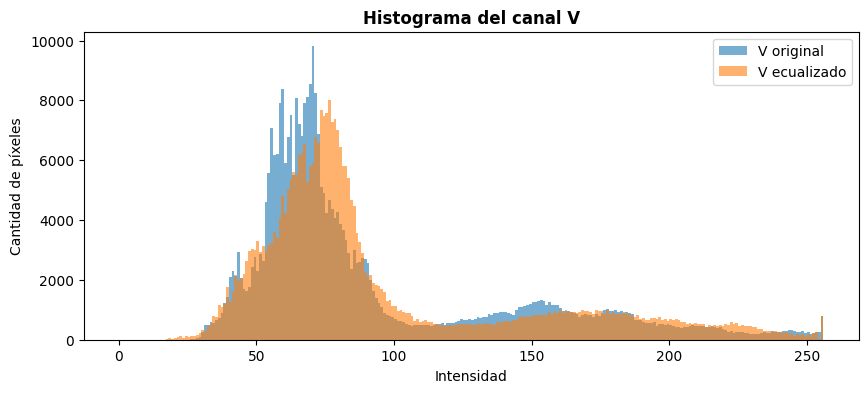

In [ ]:
# =========================
# HISTOGRAMA ANTES / DESPUES
# =========================

plt.figure(figsize=(10, 4))

plt.hist(
    v.ravel(),
    bins=256,
    range=(0, 256),
    alpha=0.6,
    label="V original"
)

plt.hist(
    v_ecualizado.ravel(),
    bins=256,
    range=(0, 256),
    alpha=0.6,
    label="V ecualizado"
)

plt.title(
    "Histograma del canal V",
    fontweight="bold"
)

plt.xlabel("Intensidad")
plt.ylabel("Cantidad de píxeles")

plt.legend()

plt.show()

La comparación entre ambos histogramas permite observar cómo la ecualización modificó la distribución del brillo en la imagen. Mientras que la captura original concentraba la mayoría de los valores en zonas oscuras, la versión procesada presenta una distribución tonal más equilibrada. Esto permitió mejorar la legibilidad de la proyección manteniendo el comportamiento óptico característico de la cámara oscura.

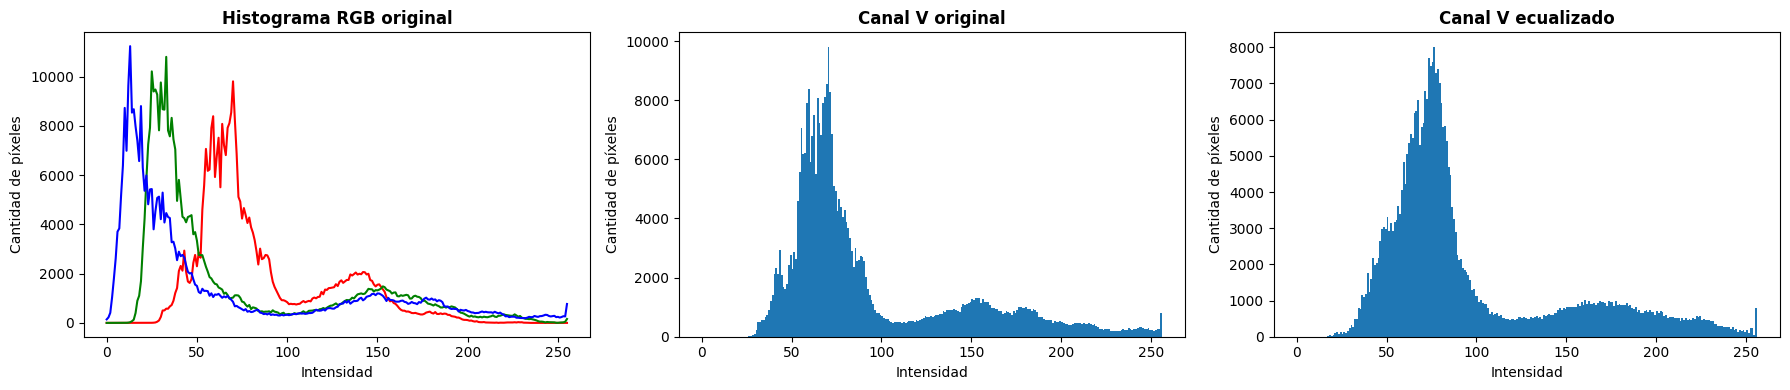

In [ ]:
# =========================
# COMPARACION DE HISTOGRAMAS
# =========================

plt.figure(figsize=(18, 4))


# =========================
# HISTOGRAMA RGB ORIGINAL
# =========================

plt.subplot(1, 3, 1)

colores = ("red", "green", "blue")

for i, color in enumerate(colores):

    histograma = cv2.calcHist(
        [camara_oscura_recorte],
        [i],
        None,
        [256],
        [0, 256]
    )

    plt.plot(histograma, color=color)

plt.title(
    "Histograma RGB original",
    fontweight="bold"
)

plt.xlabel("Intensidad")
plt.ylabel("Cantidad de píxeles")


# =========================
# HISTOGRAMA V ORIGINAL
# =========================

plt.subplot(1, 3, 2)

plt.hist(
    v.ravel(),
    bins=256,
    range=(0, 256)
)

plt.title(
    "Canal V original",
    fontweight="bold"
)

plt.xlabel("Intensidad")
plt.ylabel("Cantidad de píxeles")


# =========================
# HISTOGRAMA V ECUALIZADO
# =========================

plt.subplot(1, 3, 3)

plt.hist(
    v_ecualizado.ravel(),
    bins=256,
    range=(0, 256)
)

plt.title(
    "Canal V ecualizado",
    fontweight="bold"
)

plt.xlabel("Intensidad")
plt.ylabel("Cantidad de píxeles")


plt.tight_layout()
plt.show()

Histograma RGB original

En el histograma RGB original se observa un predominio del canal rojo respecto de los canales verde y azul. Esto evidencia una dominante cálida generada por las condiciones internas de la cámara oscura y la baja cantidad de luz disponible durante la proyección.

Histograma Canal V original

El histograma original del canal V presenta una fuerte concentración de píxeles en intensidades bajas y medias. Esto indica una imagen de bajo contraste y escasa luminosidad, característica típica de una proyección obtenida mediante cámara oscura.

Histograma Canal V ecualizado

Luego de aplicar CLAHE sobre el canal V, los valores de intensidad se distribuyen de manera más amplia a lo largo del histograma. Esto mejora la separación entre luces y sombras y permite recuperar detalles de la proyección sin generar una sobreexposición excesiva.


La comparación entre ambos histogramas demuestra cómo el procesamiento sobre el canal V permitió ampliar el rango tonal de la imagen manteniendo la estructura cromática original. La ecualización mejoró el contraste y la lectura visual de la proyección sin alterar directamente los canales de color RGB.


In [ ]:
# =========================
# EXPORTACION COMPLETA
# =========================

from pathlib import Path
from google.colab import files
import zipfile
import os

# Carpeta temporal local
carpeta_exportacion = Path("exportacion_hsv")
carpeta_exportacion.mkdir(
    parents=True,
    exist_ok=True
)

# =========================
# EXPORTAR IMAGEN ORIGINAL
# =========================

cv2.imwrite(
    str(carpeta_exportacion / "01_original_recortada.jpg"),
    cv2.cvtColor(
        camara_oscura_recorte,
        cv2.COLOR_RGB2BGR
    )
)

# =========================
# EXPORTAR IMAGEN ECUALIZADA
# =========================

cv2.imwrite(
    str(carpeta_exportacion / "02_ecualizada_clahe.jpg"),
    cv2.cvtColor(
        camara_oscura_ecualizada_rgb,
        cv2.COLOR_RGB2BGR
    )
)

# =========================
# EXPORTAR COMPARACION FINAL
# =========================

plt.figure(figsize=(12, 8))

plt.subplot(1, 2, 1)
plt.imshow(camara_oscura_recorte)
plt.title("Original recortada", fontweight="bold")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(camara_oscura_ecualizada_rgb)
plt.title("CLAHE sobre canal V", fontweight="bold")
plt.axis("off")

plt.tight_layout()

plt.savefig(
    carpeta_exportacion / "03_comparacion_final.png",
    bbox_inches="tight",
    dpi=300
)

plt.close()

# =========================
# EXPORTAR HISTOGRAMAS
# =========================

plt.figure(figsize=(18, 4))

# RGB ORIGINAL
plt.subplot(1, 3, 1)

colores = ("red", "green", "blue")

for i, color in enumerate(colores):

    histograma = cv2.calcHist(
        [camara_oscura_recorte],
        [i],
        None,
        [256],
        [0, 256]
    )

    plt.plot(histograma, color=color)

plt.title(
    "Histograma RGB original",
    fontweight="bold"
)

plt.xlabel("Intensidad")
plt.ylabel("Cantidad de píxeles")


# V ORIGINAL
plt.subplot(1, 3, 2)

plt.hist(
    v.ravel(),
    bins=256,
    range=(0, 256)
)

plt.title(
    "Canal V original",
    fontweight="bold"
)

plt.xlabel("Intensidad")
plt.ylabel("Cantidad de píxeles")


# V ECUALIZADO
plt.subplot(1, 3, 3)

plt.hist(
    v_ecualizado.ravel(),
    bins=256,
    range=(0, 256)
)

plt.title(
    "Canal V ecualizado",
    fontweight="bold"
)

plt.xlabel("Intensidad")
plt.ylabel("Cantidad de píxeles")

plt.tight_layout()

plt.savefig(
    carpeta_exportacion / "04_histogramas.png",
    bbox_inches="tight",
    dpi=300
)

plt.close()

# =========================
# CREAR ZIP
# =========================

nombre_zip = "resultados_hsv.zip"

with zipfile.ZipFile(nombre_zip, "w") as zipf:

    for archivo in carpeta_exportacion.iterdir():

        zipf.write(
            archivo,
            arcname=archivo.name
        )

# =========================
# DESCARGA DIRECTA
# =========================

files.download(nombre_zip)

print("Exportacion completa finalizada.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Exportacion completa finalizada.
